In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
from sklearn.datasets import make_classification

In [8]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,
                        n_clusters_per_class=2,n_redundant=0)

In [9]:
pd.DataFrame(X)[0]

0      1.035084
1     -1.056798
2      1.775242
3     -0.468740
4     -0.739173
         ...   
995    1.564192
996   -0.798384
997   -1.578813
998    1.094860
999   -0.799458
Name: 0, Length: 1000, dtype: float64

<AxesSubplot: xlabel='0', ylabel='1'>

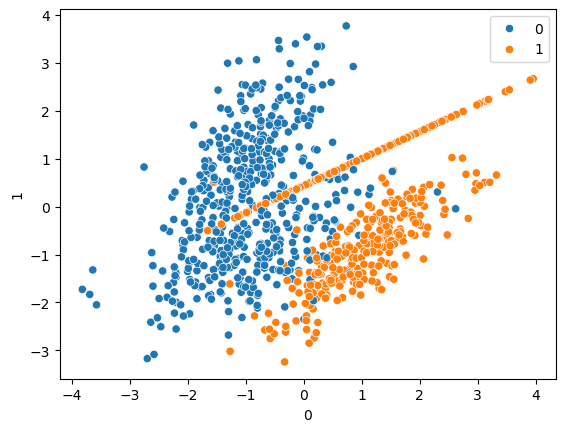

In [10]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=10)

In [12]:
from sklearn.svm import SVC

In [13]:
svc = SVC(kernel='linear')

In [14]:
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [15]:
# prediction part comes here
y_pred = svc.predict(X_test)

In [16]:
from sklearn.metrics import classification_report,confusion_matrix

In [17]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       123
           1       0.93      0.87      0.90       127

    accuracy                           0.90       250
   macro avg       0.91      0.90      0.90       250
weighted avg       0.91      0.90      0.90       250

[[115   8]
 [ 16 111]]


In [18]:
#using rbf kernel
rbf = SVC(kernel='rbf')

In [19]:
rbf.fit(X_train,y_train)

SVC()

In [20]:
y_pred1 = svc.predict(X_test)

In [21]:
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       123
           1       0.93      0.87      0.90       127

    accuracy                           0.90       250
   macro avg       0.91      0.90      0.90       250
weighted avg       0.91      0.90      0.90       250

[[115   8]
 [ 16 111]]


In [22]:
#using polynomial kernel
polynomial = SVC(kernel='poly')

In [23]:
polynomial.fit(X_train,y_train)

SVC(kernel='poly')

In [24]:
y_pred2 = svc.predict(X_test)

In [25]:
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       123
           1       0.93      0.87      0.90       127

    accuracy                           0.90       250
   macro avg       0.91      0.90      0.90       250
weighted avg       0.91      0.90      0.90       250

[[115   8]
 [ 16 111]]


In [26]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(X_train,y_train)
## Prediction
y_pred3=sigmoid.predict(X_test)
print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       123
           1       0.77      0.77      0.77       127

    accuracy                           0.77       250
   macro avg       0.77      0.77      0.77       250
weighted avg       0.77      0.77      0.77       250

[[94 29]
 [29 98]]


## HyperParameter Tuning


In [27]:
from sklearn.model_selection import GridSearchCV
 
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

In [28]:
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)

In [29]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.860 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.860 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.880 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [30]:
grid.best_params_

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}

In [31]:
## Prediction
y_pred4=grid.predict(X_test)
print(classification_report(y_test,y_pred4))
print(confusion_matrix(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       123
           1       0.95      0.93      0.94       127

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250

[[115   8]
 [ 16 111]]


## SVM Kerels Indepth Intuition And Practical Explanation

In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
x = np.linspace(-3.0,5.0,100)
y = np.sqrt(10**2 - x**2)
y= np.hstack([y,-y])
x= np .hstack([x,-x])

In [34]:
x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(5**2 -x1**2)
y1 = np.hstack([y1,-y1])
x1 = np .hstack([x1,-x1])

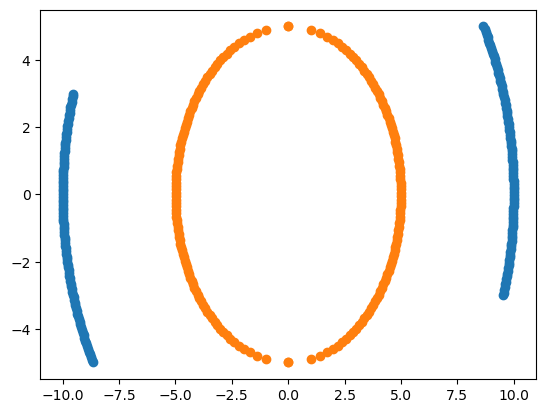

In [35]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [36]:
import pandas as pd
import numpy as np
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['X1', 'X2'])
df1['Y'] = 0
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,X1,X2,Y
0,9.539392,-3.000000,0
1,9.564430,-2.919192,0
2,9.588721,-2.838384,0
3,9.612272,-2.757576,0
4,9.635088,-2.676768,0


In [37]:
# divdin the the features into dept and indept ones
X = df.iloc[:,:2]
y = df.Y

In [38]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [39]:
# we need to find componenets for the polynomial kernel
# x1,x2,x1_square,x1_square,x1*x2
df['X1_Square'] = df['X1']**2
df['X2_Square'] = df['X2']**2
df['X1*X2'] = (df['X1'] * df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,9.539392,-3.000000,0,91.000000,9.000000,-28.618176
1,9.564430,-2.919192,0,91.478319,8.521681,-27.920406
2,9.588721,-2.838384,0,91.943577,8.056423,-27.216472
3,9.612272,-2.757576,0,92.395776,7.604224,-26.506569
4,9.635088,-2.676768,0,92.834915,7.165085,-25.790891


In [40]:
## Indept and Dept features
X = df[['X1','X2','X1_Square','X2_Square','X1*X2']]
y = df['Y']

In [41]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [ ]:
import plotly.express as px
fig = px.scatter_3d(df,x='X1',y = 'X2',z = 'X1*X2',color = 'Y')
fig.show()

In [59]:
fig = px.scatter_3d(df,x='X1_Square',y = 'X2_Square',z = 'X1*X2',color = 'Y')
fig.show()

In [60]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel = 'linear')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [61]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel = 'poly')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [62]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel = 'rbf')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [65]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier = SVC(kernel = 'sigmoid')
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0